# Case-04：側移單跨剛架 (Sway Single-Bay Frame)

承接 Case-03，本 Case 拿掉「無側移」假設，多一個側移角 Δ 的自由度、多一條剪力平衡方程式。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 門型剛架，A、D兩柱底固定，柱高H相同，B點承受水平集中載重P |
| H | 4.0 m |
| L | 6.0 m |
| P | 12.0 kN |
| Dk (獨立位移自由度) | 3 (θ_B, θ_C, ψ=Δ/H) |

## 本 Case 新增的概念
水平力 P 讓構架側移，B、C 兩點會一起產生水平位移——跟 Case-03 唯一的差別是多了 ψ=Δ/H 這個自由度，跟對應的整體剪力平衡方程式(ΣFx=0，柱剪力要跟外加水平力平衡)。如果誤判成無側移，方程式數量會跟未知數對不上。

## FEM 慣例
近端負、遠端正（傳統教科書慣例），跟 Case-01/02/03 統一。

## 0. 安裝套件

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


## 1. 框架本體 (與其他 Case 共用)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from abc import ABC, abstractmethod

sp.init_printing()

# ============================================================
# 環境偵測：同一份程式碼要能在 Jupyter/Colab (有 IPython kernel，
# display()/plt.show() 都能正常渲染) 跟純終端機/VSCode直接執行
# (python3 xxx.py，沒有IPython kernel，display()只會印物件repr、
# plt.show()在沒有視窗系統時什麼都不會顯示) 兩種環境都正常運作。
# ============================================================
try:
    from IPython import get_ipython
    _ipy = get_ipython()
    IN_NOTEBOOK = _ipy is not None and hasattr(_ipy, 'kernel')
except ImportError:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    from IPython.display import Markdown, display
else:
    class Markdown:
        """純終端機環境用的Markdown替代品：只存文字，print時原樣印出
        (不渲染標題#、粗體**這些語法，但內容完整可讀)。"""
        def __init__(self, text):
            self.text = text

    def display(obj):
        """純終端機環境用的display()替代品："""
        if isinstance(obj, Markdown):
            print(obj.text)
        elif isinstance(obj, sp.Basic):
            sp.pprint(obj)
        else:
            print(obj)

_fig_counter = [0]


def _show_fig(prefix="figure"):
    """
    取代裸的 plt.show()：Jupyter/Colab 環境正常顯示；純終端機環境沒有
    畫面可以顯示，改成存檔到當前目錄並印出檔名，不會讓圖「憑空消失」。
    """
    if IN_NOTEBOOK:
        plt.show()
    else:
        _fig_counter[0] += 1
        fname = f"{prefix}_{_fig_counter[0]}.png"
        plt.gcf().savefig(fname, dpi=110, bbox_inches='tight')
        print(f"[圖已存檔: {fname}]")
        plt.close()


# ============================================================
# 通用互動輸入：只用 input()，不依賴 ipywidgets 這種只有特定 notebook
# 環境才有的東西——Colab、純 Linux 終端機(python3 xxx.py)、VSCode
# (不管是 Jupyter 分頁還是直接跑 .py 檔) 全部都能動。
# ============================================================
def prompt_for_params(param_specs):
    """
    param_specs: list of (name, description, default, type_cast)
    互動詢問每個參數，直接按 Enter 就用預設值。回傳 dict {name: value}。
    """
    print("=" * 50)
    print("互動輸入（直接按 Enter 使用預設值）")
    print("=" * 50)
    result = {}
    for name, desc, default, cast in param_specs:
        raw = input(f"{name} ({desc}) [預設 {default}]: ").strip()
        try:
            result[name] = cast(raw) if raw else default
        except ValueError:
            print(f"  輸入無法轉換，使用預設值 {default}")
            result[name] = default
    print("=" * 50)
    for k, v in result.items():
        print(f"  {k} = {v}")
    print("=" * 50)
    return result


# ============================================================
# 共用工具：桿件彎矩沿長度的分布 (含均佈載重 w 的一般化版本)
# ============================================================
def member_moment_curve(s, length, w, M_i, M_j):
    """
    計算桿件內部彎矩沿桿長的分布 M(s)，s 為由 i 端起算的局部座標 (0~length)。
    - 無側向載重 (w=0)：退化為 i, j 兩端值的線性內插 (柱、無載重梁適用)
    - 有均佈載重 w (力/長度)：抵滿足 M(0)=M_i, M(L)=M_j 邊界條件的拋物線
      (由 d²M/ds² = w 積分兩次求得)，可正確反映跨中彎矩，而不是被兩端值
      的直線內插蓋掉 (這對兩端彎矩接近正負對稱、但跨中另有較大彎矩的
      受均佈載重梁尤其重要)。
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return M_i + C1 * s + 0.5 * w * s**2


def member_shear_curve(s, length, w, M_i, M_j):
    """
    member_moment_curve 的對應剪力函式: V(s) = dM/ds = C1 + w*s
    (跟彎矩用同一個 C1，兩者必須自洽——這也是為什麼前幾輪都用剪力
    去反查彎矩圖畫法對不對的原因：M(s) 和 V(s) 本來就是同一個 C1
    推出來的，不會不一致)
    """
    C1 = (M_j - M_i - 0.5 * w * length**2) / length
    return C1 + w * s


def member_offset_curve(x0, y0, x1, y1, s, m_values, scale):
    """
    通用的桿件內力圖偏移座標計算，取代過去每個Case各自手寫的x/y偏移公式
    （柱一套、梁又一套，還常常寫錯方向）。

    這個函式畫出來的圖是「拉力彎矩圖」(Tension-Side Bending Moment
    Diagram)：偏移方向就是該處實際受拉的那一側，不是單純套一個數學
    座標正負號——已經用最單純無爭議的案例（懸臂梁，全長已知受拉側
    唯一）驗證過 anastruct 本身就是這樣畫的，我們的規則是照anastruct
    的實際輸出反推校準出來的，跟它一致。這也是為什麼看這張圖就能
    直接判斷配筋位置，不用再心算正負號對應哪一側。

    規則: 偏移方向 = 沿著桿件「近端(x0,y0)→遠端(x1,y1)」前進方向，
    逆時針轉90度，正值往這個方向偏移。這個規則套用在水平桿件（近端
    到遠端由左到右）會自動算出「正值往上偏移」，套用在垂直桿件（近端
    到遠端由下到上）會自動算出「正值往左偏移」——這對任意角度的桿件
    都適用，包括未來斜屋頂剛架(S-01)需要的斜桿件。

    參數:
      x0,y0,x1,y1: 桿件近端、遠端的座標
      s: 沿桿件長度的局部座標陣列 (0~length)
      m_values: 對應每個s的彎矩或剪力值 (通常是 member_moment_curve
                或 member_shear_curve 的輸出)
      scale: 縮放比例
    回傳: (x, y) 畫圖用座標陣列
    """
    length = np.hypot(x1 - x0, y1 - y0)
    dx, dy = (x1 - x0) / length, (y1 - y0) / length
    perp_x, perp_y = -dy, dx  # 逆時針90度
    frac = s / length
    base_x = x0 + frac * (x1 - x0)
    base_y = y0 + frac * (y1 - y0)
    return base_x + perp_x * m_values * scale, base_y + perp_y * m_values * scale


# ============================================================
# 策略介面 (Strategy Interface)
# ============================================================
class SlopeDeflectionProblem(ABC):
    """
    傾角變位法問題的策略介面。
    每一種結構模型（單層側移剛架、二層重力剛架...）只需要繼承這個類別，
    把「模型特有」的部分實作出來；共用的「步驟1~6」解題流程交給
    SlopeDeflectionSolver（Template Method）負責，輸出格式統一比照
    手寫詳解的呈現方式。
    """

    @abstractmethod
    def get_unknowns(self) -> dict:
        """回傳未知位移量的 sympy 符號，例如 {'theta_B': ...}"""

    @abstractmethod
    def describe(self) -> str:
        """題目文字敘述 (Markdown)：結構、幾何、材料、載重、邊界條件，用於步驟1。
        不含自由度選取的說明——那部分獨立在 describe_dof()。"""

    @abstractmethod
    def describe_dof(self) -> str:
        """
        自由度(未知位移量)選取的說明 (Markdown)，用於步驟1。跟 describe()
        分開成獨立方法，是因為這一步是整個傾角變位法最容易出錯、也最該
        覆核的地方——自由度選錯或漏掉一個，後面所有方程式都會建立在錯誤
        的基礎上，整題就全錯了，值得在輸出裡獨立成一個顯眼的區塊，
        不要被埋沒在結構描述裡面。
        """

    @abstractmethod
    def draw_geometry(self, ax):
        """畫結構幾何圖 (圖1)，用於步驟1"""

    @abstractmethod
    def build_moment_equations(self) -> dict:
        """回傳桿端彎矩符號運算式 {'M_{AB}': expr, ...}，用於步驟2"""

    @abstractmethod
    def build_equilibrium_equations(self, moments: dict) -> list:
        """
        回傳平衡方程式，用於步驟3。格式為 list[tuple[str, sp.Eq]]：
        每一條方程式搭配一句說明它是哪個節點/桿件、哪一種平衡條件
        (例如 "節點B力矩平衡 ΣM_B=0"、"C端邊界條件(滾支承) M_CB=0"、
        "整體水平力平衡 ΣFx=0")，求解器會把說明跟方程式一起印出來，
        不再只丟一堆沒有上下文的裸方程式。
        """

    def compute_reactions(self, moments_val: dict) -> dict:
        """(可選) 由彎矩回代算支承反力/軸力，用於步驟5。預設不計算。"""
        return {}

    @abstractmethod
    def draw_bmd(self, ax, moments_val: dict):
        """畫彎矩圖 (圖2)，用於步驟6"""

    def draw_sfd(self, ax, moments_val: dict) -> bool:
        """
        (可選) 畫剪力圖 (SFD)，用於步驟6。若模型有實作，回傳 True 並把圖
        畫進傳入的 ax；預設不提供 (回傳 False)，求解器會印出提示而不出圖。
        """
        return False

    def draw_tension_side(self, ax, moments_val: dict) -> bool:
        """
        (可選) 在結構圖上直接標註每個桿端的受拉/受壓側 (拉力彎矩圖的
        文字版對照)，若模型有實作，回傳 True 並把圖畫進傳入的 ax；
        預設不提供 (回傳 False)。適合搭配 member_offset_curve 的偏移
        方向來自動判斷: 偏移方向那一側 = 受拉側 (已用懸臂梁這種答案
        唯一的案例驗證過 anastruct 真的是這樣畫的)。
        """
        return False

    def draw_deformed_shape(self, ax, moments_val: dict, solution: dict) -> bool:
        """
        (可選) 在同一張圖上疊加「原始結構 + 變形後形狀」。若模型有實作，
        回傳 True 並把圖畫進傳入的 ax；預設不提供 (回傳 False)。

        做法：對每根桿件，用拉力側 M(s) 轉成材料力學 sagging 慣例
        (M_sag=-M_hog)，積分兩次 EI*u''=M_sag 得到「桿件局部座標系
        正方向」(近端->遠端逆時針轉90度) 的橫向位移，邊界條件依各桿件
        的支承/連接方式而定 (case-specific，沒辦法通用化)。**算出來的
        u(s) 一定要再套 member_offset_curve 轉成畫圖座標，不能直接當
        全域x或y用**——這是實際踩過的坑：柱子的近端->遠端方向是垂直的，
        逆時針轉90度後的「正方向」其實是全域-x，直接套全域+x會整個
        鏡像顛倒(已用anastruct的show_displacement()實際畫圖座標逐點
        驗證過，修正後精確吻合)。
        """
        return False

    def teaching_breakdown(self, moments_val: dict, reactions: dict, solution: dict) -> list:
        """
        (可選) 回傳這個模型的「教學詳解 + 評分要點」分解，用於步驟8。
        每個小題是一個 dict，需要以下 key：
          - title:         小題標題 (str)
          - problem:       題目敘述 (str)
          - concept:       概念解析 (str)
          - formula:       公式引用 (str, 可含 LaTeX)
          - substitution:  帶入數據說明 (str)
          - answer:        詳細參考答案 (str, 可含 LaTeX)
          - keywords:       關鍵字/chunk 列表 (list[str])
          - grading:        評分要點列表 (list[tuple[str, int]])，每項是
                            (要點敘述, 配分)
        預設回傳空列表 (不提供)，求解器會印出提示而不出教學詳解——
        這是刻意設計成可選的，因為每題的概念解析、配分是需要針對該
        Case 手動設計的教學內容，不是所有 Case 一開始就要準備好。
        """
        return []


# ============================================================
# Template Method：共用的「步驟1~6」解題骨架
# ============================================================
class SlopeDeflectionSolver:
    """
    通用傾角變位法求解器 (Template Method)。
    計算內容全部委託給傳入的 SlopeDeflectionProblem（Strategy），
    這個類別只負責固定不變的六步驟框架與統一格式的美化輸出。
    """

    def __init__(self, problem: SlopeDeflectionProblem):
        self.problem = problem

    @staticmethod
    def _step_header(n, title):
        print("\n" + "=" * 60)
        print(f"【步驟 {n}】{title}")
        print("=" * 60)

    def _solve_core(self):
        """純計算，不印任何東西：算出 moments、平衡方程式、解、回代結果、反力。
        solve_and_report() 跟 print_teaching_handout() 共用這段，避免兩邊各算一次
        還可能算出不一樣結果的風險。"""
        p = self.problem
        moments = p.build_moment_equations()
        labeled_eqs = p.build_equilibrium_equations(moments)
        eqs = [eq for _, eq in labeled_eqs]
        unknowns = p.get_unknowns()
        sol = sp.solve(eqs, tuple(unknowns.values()))
        moments_val = {name: float(expr.subs(sol)) for name, expr in moments.items()}
        reactions = p.compute_reactions(moments_val)
        return moments, labeled_eqs, unknowns, sol, moments_val, reactions

    @staticmethod
    def _annotate_tension_note(ax):
        """
        在彎矩圖上加一行小提示，說明這張圖是拉力側繪製慣例——用英文避免
        matplotlib預設字型(DejaVu Sans)缺中文字產生的警告(之前踩過這個坑，
        中文標題會在Colab印出一長串UserWarning)。詳細的中文說明放在
        print_teaching_handout()的Markdown文字裡，那邊走的是Markdown/HTML
        渲染，沒有這個字型限制。
        """
        ax.text(0.5, -0.08, 'Bending moment diagram drawn on the tension side',
                transform=ax.transAxes, ha='center', fontsize=8.5,
                color='dimgray', style='italic')

    def _print_teaching_breakdown(self, moments_val, reactions, sol):
        """渲染 teaching_breakdown() 的內容 (題目/概念解析/公式引用/帶入數據/
        參考答案/關鍵字/評分要點)。solve_and_report() 的步驟8跟
        print_teaching_handout() 共用這段渲染邏輯，回傳 True/False 代表這個
        model 有沒有提供內容。"""
        p = self.problem
        breakdown = p.teaching_breakdown(moments_val, reactions, sol)
        if not breakdown:
            return False
        total_points = 0
        for i, item in enumerate(breakdown, 1):
            display(Markdown(f"### 第{i}小題：{item['title']}"))
            display(Markdown(f"**題目**：{item['problem']}"))
            display(Markdown(f"**概念解析**：{item['concept']}"))
            display(Markdown(f"**公式引用**：\n\n{item['formula']}"))
            display(Markdown(f"**帶入數據**：{item['substitution']}"))
            display(Markdown(f"**詳細參考答案**：\n\n{item['answer']}"))
            display(Markdown(f"**關鍵字/chunk**：{', '.join(item['keywords'])}"))
            pts_sum = sum(pts for _, pts in item['grading'])
            grading_lines = "\n".join(f"- {desc}（{pts}分）" for desc, pts in item['grading'])
            display(Markdown(f"**評分要點**（本小題共 {pts_sum} 分）：\n\n{grading_lines}"))
            total_points += pts_sum
        display(Markdown(f"---\n**本題總分：{total_points} 分**"))
        return True

    def print_teaching_handout(self):
        """
        產生一份純粹「繪圖」的教學輸出，不含文字推導、不含評分要點，只有
        五張圖 (a~e)，適合放在 solve_and_report() 那個 cell 的下一個 cell，
        單獨執行、單獨截圖/複製：
          a. 結構受力圖
          b. 剪力圖 (SFD)
          c. 彎矩圖 (BMD)
          d. 拉力側標註圖
          e. 變形圖
        """
        p = self.problem
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()

        display(Markdown("### a. 結構受力圖"))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")

        display(Markdown("### b. 剪力圖 (SFD)"))
        fig_sfd, ax_sfd = plt.subplots(figsize=(8, 5))
        has_sfd = p.draw_sfd(ax_sfd, moments_val)
        if has_sfd:
            _show_fig("sfd")
        else:
            plt.close(fig_sfd)
            print("(此模型尚未實作剪力圖，略過)")

        display(Markdown("### c. 彎矩圖 (BMD)"))
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        p.draw_bmd(ax2, moments_val)
        self._annotate_tension_note(ax2)
        _show_fig("bmd")
        plt.close('all')

        display(Markdown("### d. 拉力側標註圖"))
        fig_t, ax_t = plt.subplots(figsize=(8, 7))
        has_tension = p.draw_tension_side(ax_t, moments_val)
        if has_tension:
            _show_fig("tension_side")
        else:
            plt.close(fig_t)
            print("(此模型尚未實作拉力側標註圖，略過)")

        display(Markdown("### e. 變形圖"))
        fig_d, ax_d = plt.subplots(figsize=(8, 7))
        has_deformed = p.draw_deformed_shape(ax_d, moments_val, sol)
        if has_deformed:
            _show_fig("deformed")
        else:
            plt.close(fig_d)
            print("(此模型尚未實作變形圖，略過)")

    def solve_and_report(self):
        p = self.problem

        # ---------------- 步驟1：題目與幾何 ----------------
        self._step_header(1, "題目定義、幾何/材料參數與自由度標示")
        display(Markdown("**① 結構定義、幾何與邊界條件**"))
        display(Markdown(p.describe()))
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        p.draw_geometry(ax1)
        _show_fig("structure")
        display(Markdown(
            "**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在"
            "錯誤基礎上、整題全錯，是最需要覆核的一步）：\n\n" + p.describe_dof()
        ))

        # ---------------- 步驟2：桿端彎矩方程式 ----------------
        self._step_header(2, "寫出桿端彎矩方程式")
        display(Markdown(
            "**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：\n\n"
            r"$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$"
            "\n\n其中 $\\theta_i,\\theta_j$ 為兩端轉角，$\\psi=\\Delta/L$ 為側移角"
            "（無側移時 $\\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。"
        ))
        moments, labeled_eqs, unknowns, sol, moments_val, reactions = self._solve_core()
        display(Markdown(
            "**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式："
        ))
        for name, expr in moments.items():
            display(sp.Eq(sp.Symbol(name), expr))

        # ---------------- 步驟3：平衡方程式 ----------------
        self._step_header(3, "建立平衡方程式")
        display(Markdown("**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）："))
        for label, eq in labeled_eqs:
            display(Markdown(f"- {label}"))
            display(eq)

        # ---------------- 步驟4：解聯立方程式 ----------------
        self._step_header(4, "求解聯立方程式 (未知位移量)")
        display(Markdown("**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——"
                          "對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，"
                          "所以先看符號解能清楚看出這個特性）："))
        for name, sym in unknowns.items():
            display(sp.Eq(sp.Symbol(name), sol[sym]))

        EI_numeric = getattr(p, 'EI_numeric', None)
        if EI_numeric is not None:
            display(Markdown(
                f"**② 代入 EI 數值**（EI = {EI_numeric}，方便直接跟 anastruct、"
                "OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）："
            ))
            for name, sym in unknowns.items():
                val_numeric = float(sol[sym].subs(p.EI, EI_numeric))
                display(sp.Eq(sp.Symbol(name), round(val_numeric, 6)))

        # ---------------- 步驟5：回代求彎矩與反力 ----------------
        self._step_header(5, "計算真實桿端彎矩與反力")
        display(Markdown("**最終桿端彎矩計算結果 (kN·m)：**"))
        for name, val in moments_val.items():
            print(f"{name} = {val:.3f} kN·m")

        if reactions:
            print()
            for name, val in reactions.items():
                print(f"-> {name} = {val:.3f}")

        # ---------------- 步驟6：剪力圖、彎矩圖已移到 print_teaching_handout() ----------------
        # 手算詳解專注在推導過程本身，圖放在下一個cell的教學講義裡，避免重複

        return {"moments": moments_val, "reactions": reactions, "solution": sol}


## 2. Case-04 模型 (Strategy)

In [3]:
import numpy as np
import sympy as sp



class SwayFrameProblem(SlopeDeflectionProblem):
    """
    Case-04：側移單跨剛架 (Sway Single-Bay Frame)
    柱AB、CD高度相同(H)、底端固定(A,D)；梁BC跨度L，無跨間載重；
    B點承受水平集中載重P。跟Case-03(無側移)的差別只有一個：多了側移角
    Δ這個自由度、多了一條剪力平衡方程式(ΣFx=0)。

    FEM慣例：近端負、遠端正(傳統教科書慣例，順時針為正)，跟Case-01/02/03統一。
    本題FEM全部=0(沒有跨間載重)，這條慣例在數值上不受影響，但公式結構
    仍照統一寫法(方便以後有跨間載重的變化題直接套用)。
    """

    def __init__(self, H=4.0, L=6.0, P=12.0, EI_numeric=15000.0):
        self.H, self.L, self.P = H, L, P
        self.EI = sp.Symbol('EI', positive=True, real=True)
        self.theta_B, self.theta_C, self.psi = sp.symbols('theta_B theta_C psi', real=True)
        self.EI_numeric = EI_numeric

    def get_unknowns(self):
        return {'\\theta_B': self.theta_B, '\\theta_C': self.theta_C, '\\psi': self.psi}

    def describe(self):
        return (f"**柱高** $H={self.H}$ m (兩柱等高)，**梁跨** $L={self.L}$ m，"
                f"**B點水平集中載重** $P={self.P}$ kN\n\n"
                f"**邊界條件：** A、D兩端固定 ($\\theta_A=\\theta_D=0$)，"
                f"梁上無跨間載重(FEM=0)，柱身無側向載重")

    def describe_dof(self):
        return (f"A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，"
                f"各自有一個轉角 $\\theta_B, \\theta_C$。因為有水平力P作用，"
                f"這次**不能假設無側移**——柱頂B、C會一起產生水平位移Δ，"
                f"多出第三個未知量：側移角 $\\psi=\\Delta/H$(兩柱等高，側移量"
                f"相同，共用同一個ψ)。共三個未知位移量 $\\theta_B, \\theta_C, \\psi$。"
                f"對應多一條**剪力平衡方程式**(整體水平方向 ΣFx=0)，這是跟"
                f"Case-03唯一的差別——如果誤判成無側移(漏掉ψ跟剪力平衡)，"
                f"方程式數量會跟未知數對不上。")

    def draw_geometry(self, ax):
        H, L, P = self.H, self.L, self.P
        ax.plot([0, 0], [0, H], 'k-', lw=3)
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)
        for x0 in (0, L):
            ax.plot([x0 - 0.15, x0 + 0.15], [-0.02, -0.02], 'k-', lw=3)
            for dx in np.linspace(-0.12, 0.12, 5):
                ax.plot([x0 + dx, x0 + dx - 0.1], [0, -0.2], 'k-', lw=1)
        ax.text(0, -0.5, 'A (Fixed)', ha='center', fontsize=10, fontweight='bold')
        ax.text(L, -0.5, 'D (Fixed)', ha='center', fontsize=10, fontweight='bold')
        ax.text(0, H + 0.3, 'B', fontsize=12, fontweight='bold', ha='center')
        ax.text(L, H + 0.3, 'C', fontsize=12, fontweight='bold', ha='center')

        # 水平力P (畫在B點, 指向+x)
        ax.annotate('', xy=(1.0, H), xytext=(0.0, H),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
        ax.text(0.5, H + 0.35, f'$P={P}$ kN', color='red', ha='center', fontsize=11)

        # theta_B, theta_C: 統一順時針假設方向(跟Case-03同一原則)
        ax.annotate('', xy=(0.35, H + 0.9), xytext=(-0.35, H + 0.9),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(0, H + 1.3, r'$\theta_B$', color='purple', fontsize=12, ha='center')
        ax.annotate('', xy=(L + 0.35, H + 0.9), xytext=(L - 0.35, H + 0.9),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.5',
                                     color='purple', lw=2))
        ax.text(L, H + 1.3, r'$\theta_C$', color='purple', fontsize=12, ha='center')

        # psi (側移角) 標示: 代表水平側移方向, 畫在梁跨中間下方(遠離其他標籤)，
        # 箭頭指向水平(+x), 跟P同方向
        mid_x = L / 2
        ax.annotate('', xy=(mid_x + 0.6, H / 2), xytext=(mid_x - 0.6, H / 2),
                    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.8))
        ax.text(mid_x, H / 2 + 0.3, r'$\psi=\Delta/H$', color='darkorange', fontsize=10,
                ha='center')

        ax.set_xlim(-2.2, L + 2)
        ax.set_ylim(-1, H + 2)
        ax.set_aspect('equal')
        ax.set_title('Figure 1: Sway Frame — Geometry, Load & DOF')
        ax.grid(True, linestyle='--', alpha=0.5)

    def build_moment_equations(self):
        EI, H, L = self.EI, self.H, self.L
        thB, thC, psi = self.theta_B, self.theta_C, self.psi
        return {
            'M_{AB}': 2 * EI / H * (thB - 3 * psi),
            'M_{BA}': 2 * EI / H * (2 * thB - 3 * psi),
            'M_{BC}': 2 * EI / L * (2 * thB + thC),
            'M_{CB}': 2 * EI / L * (thB + 2 * thC),
            'M_{CD}': 2 * EI / H * (2 * thC - 3 * psi),
            'M_{DC}': 2 * EI / H * (thC - 3 * psi),
        }

    def build_equilibrium_equations(self, moments):
        H, P = self.H, self.P
        eq1 = sp.Eq(moments['M_{BA}'] + moments['M_{BC}'], 0)
        eq2 = sp.Eq(moments['M_{CB}'] + moments['M_{CD}'], 0)
        eq3 = sp.Eq((moments['M_{AB}'] + moments['M_{BA}']) / H +
                     (moments['M_{DC}'] + moments['M_{CD}']) / H + P, 0)
        return [
            ("節點 B 力矩平衡 ΣM_B=0（柱AB與梁BC交會） M_BA + M_BC = 0", eq1),
            ("節點 C 力矩平衡 ΣM_C=0（梁BC與柱CD交會） M_CB + M_CD = 0", eq2),
            ("整體剪力平衡 ΣFx=0（水平力P跟兩柱剪力平衡，這是本Case比Case-03多出來的方程式）"
             " (M_AB+M_BA)/H + (M_DC+M_CD)/H + P = 0", eq3),
        ]

    def compute_reactions(self, moments_val):
        H = self.H
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        H_A = (m_ab + m_ba) / H
        H_D = (m_dc + m_cd) / H
        return {'H_A (kN)': H_A, 'H_D (kN)': H_D}

    def draw_sfd(self, ax, moments_val):
        H, L = self.H, self.L
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        scale = 0.05

        ax.plot([0, 0], [0, H], 'k-', lw=3, label='Frame Structure')
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)

        s1 = np.linspace(0, H, 100)
        v1 = member_shear_curve(s1, H, 0.0, -m_ab, m_ba)
        x1, y1 = member_offset_curve(0, 0, 0, H, s1, v1, scale)
        ax.plot(x1, y1, 'b-', lw=2, label='SFD')
        ax.fill(np.append(x1, [0, 0]), np.append(y1, [H, 0]), color='blue', alpha=0.15)

        s2 = np.linspace(0, L, 200)
        v2 = member_shear_curve(s2, L, 0.0, -m_bc, m_cb)
        x2, y2 = member_offset_curve(0, H, L, H, s2, v2, scale)
        ax.plot(x2, y2, 'b-', lw=2)
        ax.fill(np.append(x2, [L, 0]), np.append(y2, [H, H]), color='blue', alpha=0.15)

        s3 = np.linspace(0, H, 100)
        v3 = member_shear_curve(s3, H, 0.0, -m_dc, m_cd)
        x3, y3 = member_offset_curve(L, 0, L, H, s3, v3, scale)
        ax.plot(x3, y3, 'b-', lw=2)
        ax.fill(np.append(x3, [L, L]), np.append(y3, [H, 0]), color='blue', alpha=0.15)

        ax.axhline(0, color='gray', lw=0.5, zorder=0)
        ax.axhline(H, color='gray', lw=0.5, zorder=0)
        for xx, yy, val, ha in [(x1[0], y1[0], v1[0], 'right'), (x1[-1], y1[-1], v1[-1], 'right'),
                                 (x2[0], y2[0], v2[0], 'left'), (x2[-1], y2[-1], v2[-1], 'right'),
                                 (x3[0], y3[0], v3[0], 'left'), (x3[-1], y3[-1], v3[-1], 'left')]:
            ax.text(xx, yy, f'{val:.1f}', color='darkblue', fontsize=8, ha=ha)

        ax.set_xlim(-3, L + 3)
        ax.set_ylim(-1, H + 2)
        ax.set_aspect('equal')
        ax.set_title('Figure: Shear Force Diagram (SFD) [kN]')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right')
        return True

    def draw_tension_side(self, ax, moments_val):
        H, L = self.H, self.L
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']

        ax.plot([0, 0], [0, H], 'k-', lw=4)
        ax.plot([0, L], [H, H], 'k-', lw=4)
        ax.plot([L, L], [H, 0], 'k-', lw=4)

        labels = [
            (0, 0, 0, 1, -m_ab),
            (0, H, 0, 1, m_ba),
            (0, H, 1, 0, -m_bc),
            (L, H, 1, 0, m_cb),
            (L, H, 0, 1, m_cd),
            (L, 0, 0, 1, -m_dc),
        ]
        for x, y, dx, dy, val in labels:
            perp_x, perp_y = -dy, dx
            sign = 1 if val > 0 else -1
            tx, ty = x + perp_x * sign * 0.9, y + perp_y * sign * 0.9
            cx, cy = x - perp_x * sign * 0.9, y - perp_y * sign * 0.9
            ax.annotate('TENSION', xy=(x, y), xytext=(tx, ty), color='red',
                        fontsize=9, fontweight='bold', ha='center',
                        arrowprops=dict(arrowstyle='->', color='red'))
            ax.annotate('compression', xy=(x, y), xytext=(cx, cy), color='blue',
                        fontsize=8, ha='center',
                        arrowprops=dict(arrowstyle='->', color='blue', alpha=0.6))
            ax.text(x, y - 0.35 if y == 0 else y + 0.35, f'M={val:.1f}',
                    fontsize=8, ha='center', color='black')

        ax.set_xlim(-2.5, L + 2.5)
        ax.set_ylim(-1.5, H + 2)
        ax.set_aspect('equal')
        ax.set_title('Figure: Tension/Compression Side by Member')
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_deformed_shape(self, ax, moments_val, solution):
        H, L = self.H, self.L
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        EI_val = self.EI_numeric
        theta_B = float(solution[self.theta_B].subs(self.EI, EI_val))


        def transverse_u(s_arr, M_i, M_j, length, w_load, u0, up0):
            C1 = (M_j - M_i - 0.5 * w_load * length**2) / length
            return (u0 + up0 * s_arr + (1.0 / EI_val) *
                    (-M_i * s_arr**2 / 2 - C1 * s_arr**3 / 6 - w_load * s_arr**4 / 24))

        scale = 80
        s_col = np.linspace(0, H, 100)
        s_beam = np.linspace(0, L, 100)

        # 柱AB: 近端A(固定,u=0,u'=0) -> 遠端B。這次(有側移)不強制u(H)=0，
        # 讓它自然積分出來的值就是側移量Δ，跟Case-03(無側移)不一樣
        u_AB = transverse_u(s_col, -m_ab, m_ba, H, 0.0, u0=0, up0=0)
        # 梁BC: 近端B(u=0,u'=-theta_B已知,連續節點) -> 遠端C
        u_BC = transverse_u(s_beam, -m_bc, m_cb, L, 0.0, u0=0, up0=-theta_B)
        # 柱CD: 近端D(固定,u=0,u'=0) -> 遠端C
        u_CD = transverse_u(s_col, -m_dc, m_cd, H, 0.0, u0=0, up0=0)

        x_AB, y_AB = member_offset_curve(0, 0, 0, H, s_col, u_AB, scale)

        # 梁BC的起點、終點要用柱頂「實際偏移後」的座標，不能假設柱頂還在
        # x=0/x=L——柱子有側移，頂端已經橫向偏移過去了(這是這次抓到的bug：
        # 梁原本固定用(0,H)->(L,H)當基準，沒有跟著柱頂的真實偏移量走，
        # 造成梁跟柱在B、C兩個節點對不起來、畫出來斷開)
        x_B_actual, y_B_actual = x_AB[-1], y_AB[-1]

        x_CD, y_CD = member_offset_curve(L, 0, L, H, s_col, u_CD, scale)
        x_C_actual, y_C_actual = x_CD[-1], y_CD[-1]

        x_BC, y_BC = member_offset_curve(x_B_actual, y_B_actual,
                                          x_C_actual, y_C_actual, s_beam, u_BC, scale)

        ax.plot([0, 0], [0, H], '--', color='gray', lw=2, label='Original Structure')
        ax.plot([0, L], [H, H], '--', color='gray', lw=2)
        ax.plot([L, L], [H, 0], '--', color='gray', lw=2)
        ax.plot(x_AB, y_AB, 'b-', lw=2.5, label=f'Deformed Shape (x{scale} scale)')
        ax.plot(x_BC, y_BC, 'b-', lw=2.5)
        ax.plot(x_CD, y_CD, 'b-', lw=2.5)

        for x0 in (0, L):
            ax.plot([x0 - 0.15, x0 + 0.15], [-0.02, -0.02], 'k-', lw=3)
            for dx in np.linspace(-0.12, 0.12, 5):
                ax.plot([x0 + dx, x0 + dx - 0.1], [0, -0.2], 'k-', lw=1)

        ax.set_xlim(-2, L + 3)
        ax.set_ylim(-1, H + 1.5)
        ax.set_aspect('equal')
        ax.set_title('Sway Frame: Original vs Deformed Shape')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
        ax.grid(True, linestyle='--', alpha=0.4)
        return True

    def draw_bmd(self, ax, moments_val):
        H, L = self.H, self.L
        m_ab, m_ba = moments_val['M_{AB}'], moments_val['M_{BA}']
        m_bc, m_cb = moments_val['M_{BC}'], moments_val['M_{CB}']
        m_cd, m_dc = moments_val['M_{CD}'], moments_val['M_{DC}']
        scale = 0.06

        ax.plot([0, 0], [0, H], 'k-', lw=3, label='Frame Structure')
        ax.plot([0, L], [H, H], 'k-', lw=3)
        ax.plot([L, L], [H, 0], 'k-', lw=3)

        s1 = np.linspace(0, H, 200)
        m1 = member_moment_curve(s1, H, 0.0, -m_ab, m_ba)
        x1, y1 = member_offset_curve(0, 0, 0, H, s1, m1, scale)
        ax.plot(x1, y1, 'r--', lw=2, label='BMD')
        ax.fill(np.append(x1, [0, 0]), np.append(y1, [H, 0]), color='red', alpha=0.15)

        s2 = np.linspace(0, L, 200)
        m2 = member_moment_curve(s2, L, 0.0, -m_bc, m_cb)
        x2, y2 = member_offset_curve(0, H, L, H, s2, m2, scale)
        ax.plot(x2, y2, 'r--', lw=2)
        ax.fill(np.append(x2, [L, 0]), np.append(y2, [H, H]), color='red', alpha=0.15)

        s3 = np.linspace(0, H, 200)
        m3 = member_moment_curve(s3, H, 0.0, -m_dc, m_cd)
        x3, y3 = member_offset_curve(L, 0, L, H, s3, m3, scale)
        ax.plot(x3, y3, 'r--', lw=2)
        ax.fill(np.append(x3, [L, L]), np.append(y3, [H, 0]), color='red', alpha=0.15)

        ax.axhline(0, color='gray', lw=0.5, zorder=0)
        ax.axhline(H, color='gray', lw=0.5, zorder=0)

        ax.text(x1[0], y1[0], f'{m1[0]:.1f}', color='darkred', fontsize=8, ha='right', va='top')
        ax.text(x1[-1], y1[-1], f'{m1[-1]:.1f}', color='darkred', fontsize=8, ha='right', va='bottom')
        ax.text(x2[0], y2[0], f'{m2[0]:.1f}', color='darkred', fontsize=8, ha='left', va='bottom')
        ax.text(x2[-1], y2[-1], f'{m2[-1]:.1f}', color='darkred', fontsize=8, ha='right', va='bottom')
        ax.text(x3[-1], y3[-1], f'{m3[-1]:.1f}', color='darkred', fontsize=8, ha='left', va='bottom')
        ax.text(x3[0], y3[0], f'{m3[0]:.1f}', color='darkred', fontsize=8, ha='left', va='top')

        ax.set_xlim(-4, L + 4)
        ax.set_ylim(-1, H + 3)
        ax.set_aspect('equal')
        ax.set_title('Figure: Bending Moment Diagram (BMD) [kN·m]')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right')


## 3. 求解並產生「手寫詳解」風格輸出（步驟1~7）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**柱高** $H=4.0$ m (兩柱等高)，**梁跨** $L=6.0$ m，**B點水平集中載重** $P=12.0$ kN

**邊界條件：** A、D兩端固定 ($\theta_A=\theta_D=0$)，梁上無跨間載重(FEM=0)，柱身無側向載重

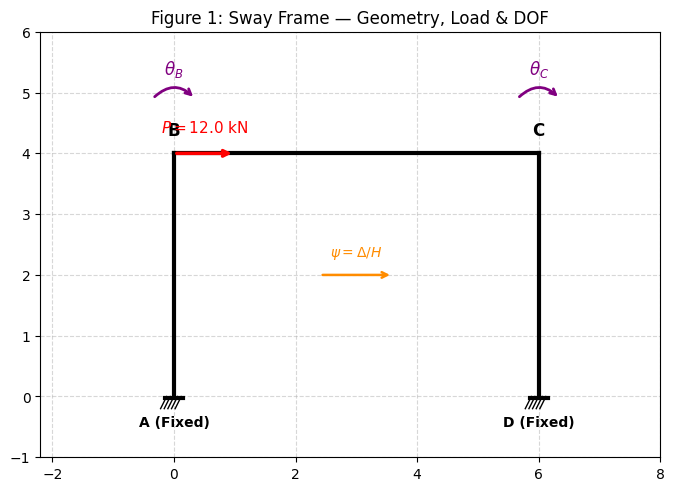

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，各自有一個轉角 $\theta_B, \theta_C$。因為有水平力P作用，這次**不能假設無側移**——柱頂B、C會一起產生水平位移Δ，多出第三個未知量：側移角 $\psi=\Delta/H$(兩柱等高，側移量相同，共用同一個ψ)。共三個未知位移量 $\theta_B, \theta_C, \psi$。對應多一條**剪力平衡方程式**(整體水平方向 ΣFx=0)，這是跟Case-03唯一的差別——如果誤判成無側移(漏掉ψ跟剪力平衡)，方程式數量會跟未知數對不上。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（柱AB與梁BC交會） M_BA + M_BC = 0

- 節點 C 力矩平衡 ΣM_C=0（梁BC與柱CD交會） M_CB + M_CD = 0

- 整體剪力平衡 ΣFx=0（水平力P跟兩柱剪力平衡，這是本Case比Case-03多出來的方程式） (M_AB+M_BA)/H + (M_DC+M_CD)/H + P = 0


【步驟 4】求解聯立方程式 (未知位移量)


**① 符號解**（保留 EI 符號，這是傾角變位法教學上的標準步驟——對單一材料/均勻EI的靜不定結構，解出來的桿端彎矩最終會跟EI無關，所以先看符號解能清楚看出這個特性）：

**② 代入 EI 數值**（EI = 15000.0，方便直接跟 anastruct、OpenSeesPy 這類數值工具的結果對照，不用自己心算分數/小數）：


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = -14.400 kN·m
M_{BA} = -9.600 kN·m
M_{BC} = 9.600 kN·m
M_{CB} = 9.600 kN·m
M_{CD} = -9.600 kN·m
M_{DC} = -14.400 kN·m

-> H_A (kN) = -6.000
-> H_D (kN) = -6.000


{'moments': {'M_{AB}': -14.400000000000002,
  'M_{BA}': -9.600000000000003,
  'M_{BC}': 9.599999999999998,
  'M_{CB}': 9.599999999999998,
  'M_{CD}': -9.600000000000003,
  'M_{DC}': -14.400000000000002},
 'reactions': {'H_A (kN)': -6.000000000000002, 'H_D (kN)': -6.000000000000002},
 'solution': {psi: 12.8/EI, theta_B: 9.6/EI, theta_C: 9.6/EI}}

In [4]:
problem = SwayFrameProblem(H=4.0, L=6.0, P=12.0, EI_numeric=15000.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 3b. 教學講義輸出（只有五張圖：結構受力圖／剪力圖／彎矩圖／拉力側標註圖／變形圖）

### a. 結構受力圖

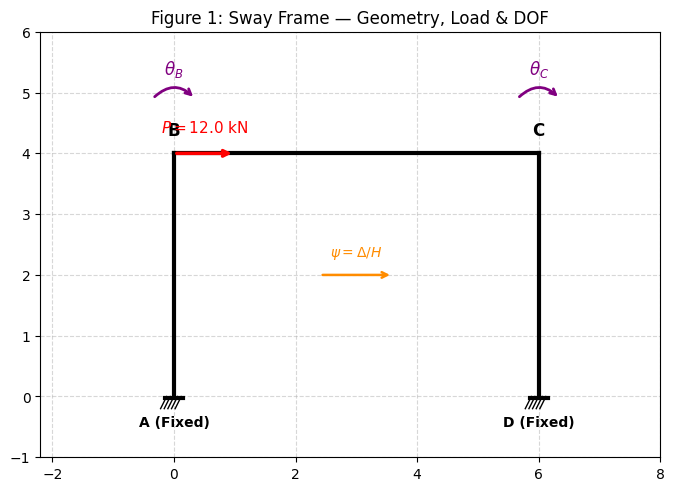

### b. 剪力圖 (SFD)

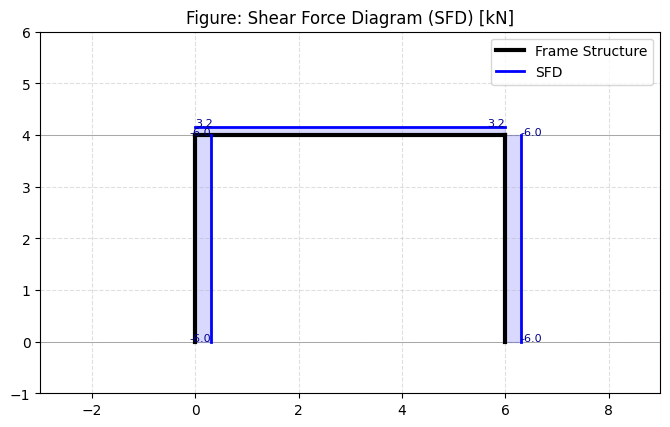

### c. 彎矩圖 (BMD)

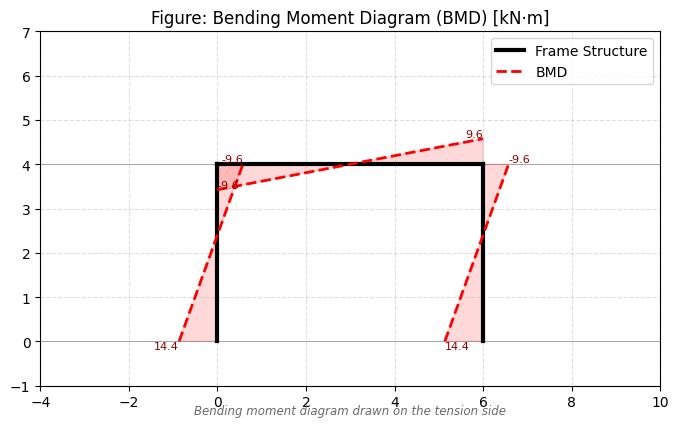

### d. 拉力側標註圖

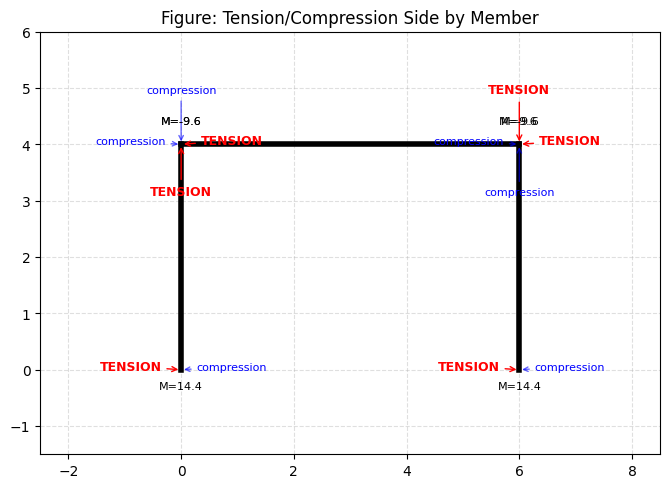

### e. 變形圖

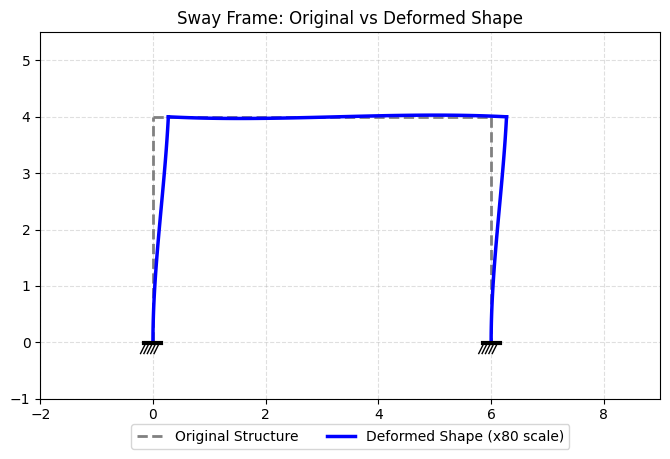

In [5]:
solver.print_teaching_handout()

## 4. anastruct 獨立建模驗證

B點側移: -0.0034135815924454444


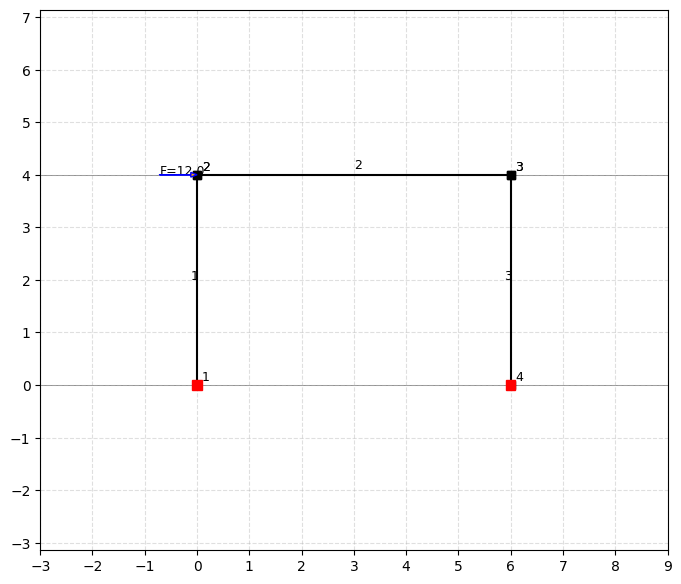

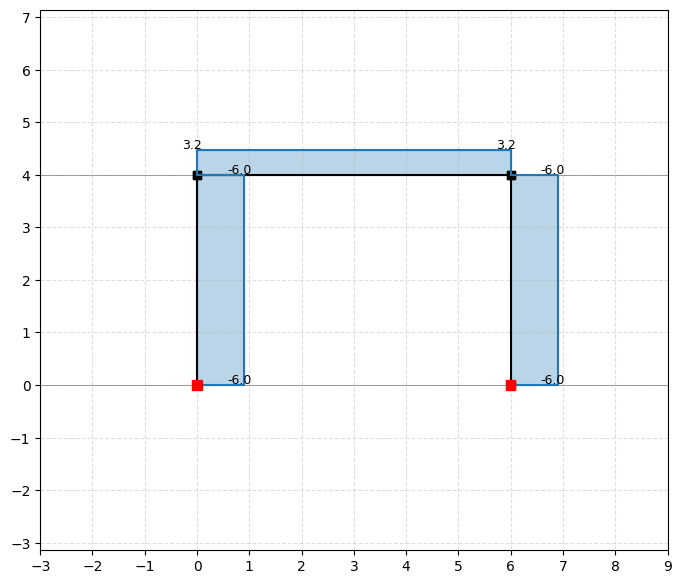

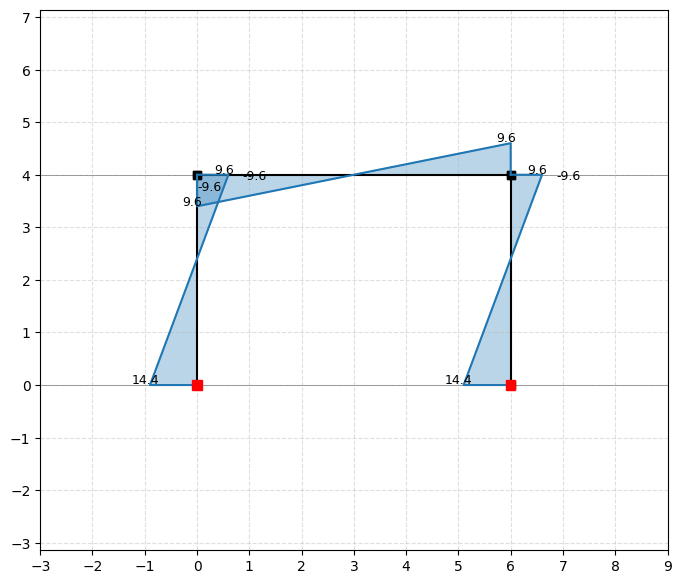

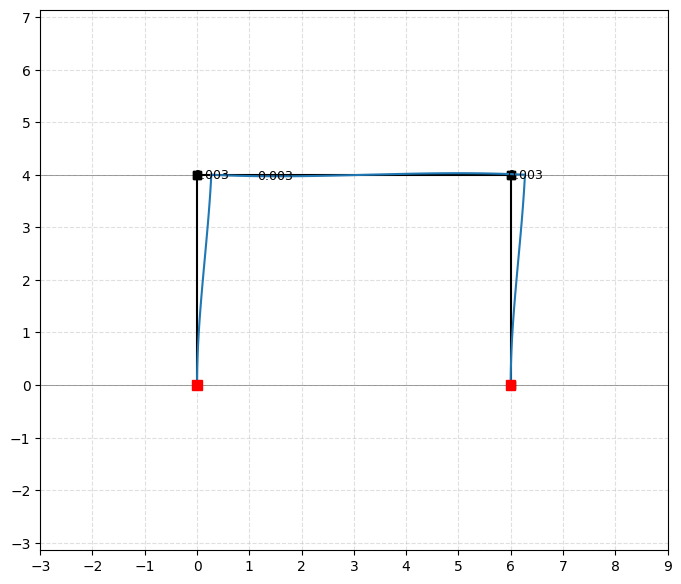

In [6]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

H, L, P = 4.0, 6.0, 12.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [0, H]])
ss.add_element(location=[[0, H], [L, H]])
ss.add_element(location=[[L, 0], [L, H]])  # 跟柱AB同方向(由下往上)定義
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=4)
ss.point_load(node_id=2, Fx=P)
ss.solve()

print("B點側移:", ss.get_node_results_system(2)['ux'])

def apply_grid(fig, y_lines=()):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for y in y_lines:
        ax.axhline(y, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(7, 6))
apply_grid(fig_s, [0, H])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(7, 6))
apply_grid(fig_v, [0, H])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(7, 6))
apply_grid(fig_m, [0, H])
plt.show()

fig_d = ss.show_displacement(show=False, factor=80, figsize=(7, 6))
apply_grid(fig_d, [0, H])
plt.show()

## 5. 反力交叉檢查

In [7]:
m_ab, m_ba = -14.4, -9.6
m_cd, m_dc = -9.6, -14.4
H_A = (m_ab + m_ba) / H
H_D = (m_dc + m_cd) / H
print(f"我們框架推算: H_A={H_A:.3f}  H_D={H_D:.3f}  (加總應等於-P={-P})")
print(f"加總: {H_A + H_D:.3f}")
assert abs(H_A + H_D + P) < 0.01
print("\n反力交叉檢查通過 ✓")

我們框架推算: H_A=-6.000  H_D=-6.000  (加總應等於-P=-12.0)
加總: -12.000

反力交叉檢查通過 ✓
